
================ TASK 1: CUSTOMER SEGMENTATION ================

Dataset shape: (200, 4)
   customer_id  age  income  spending_score
0            1   45   57155              10
1            2   38   61215              35
2            3   47   71661              50
3            4   58   71076              51
4            5   37   22446              38

=== CLUSTERING WITHOUT SCALING ===
Silhouette Score: 0.5482
Cluster centers:
[[3.74266667e+01 3.26908667e+04 5.00533333e+01]
 [3.99042553e+01 5.73424468e+04 4.47659574e+01]
 [4.08064516e+01 8.22763871e+04 4.86774194e+01]]

=== CLUSTERING WITH SCALING (excluding age) ===
Silhouette Score: 0.5142
Cluster centers:
[[ 5.43809524e+01 -7.96443764e-03 -1.38926410e-01]
 [ 2.66984127e+01 -2.00261109e-01  1.39436135e-01]
 [ 4.06000000e+01  1.36325855e-01 -3.10480764e-02]]

=== COMPARISON ===
Silhouette Score without scaling: 0.5482
Silhouette Score with scaling: 0.5142
Customers that changed cluster after scaling: 144 out of 200

Confusion matrix 

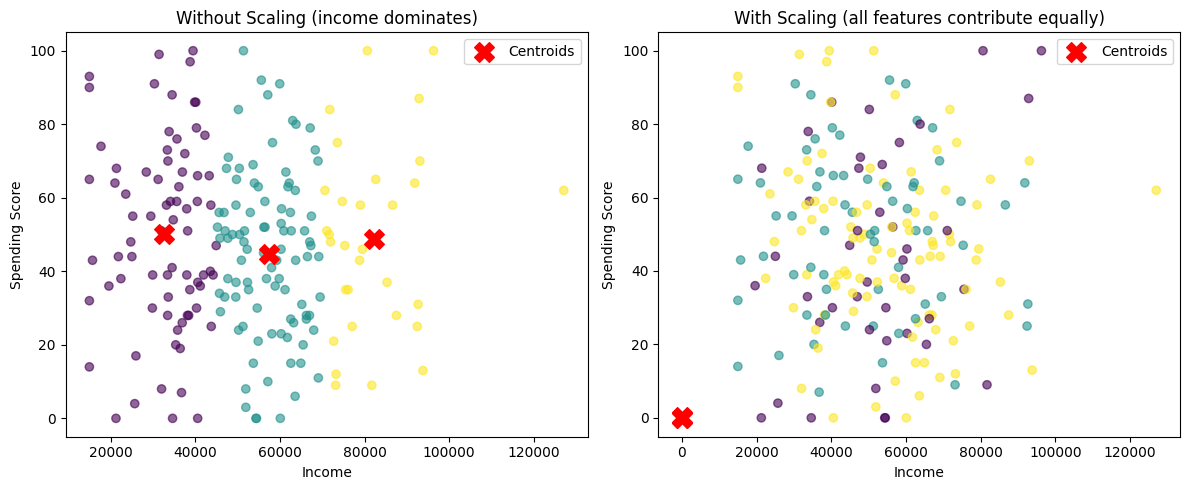

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("\n================ TASK 1: CUSTOMER SEGMENTATION ================")

np.random.seed(42)
n_samples = 200

df = pd.DataFrame({
    "customer_id": range(1, n_samples + 1),
    "age": np.random.normal(40, 12, n_samples).clip(18, 80).astype(int),
    "income": np.random.normal(50000, 20000, n_samples).clip(15000, 150000).astype(int),
    "spending_score": np.random.normal(50, 25, n_samples).clip(0, 100).astype(int)
})

print("\nDataset shape:", df.shape)
print(df.head())

X = df.drop("customer_id", axis=1)

print("\n=== CLUSTERING WITHOUT SCALING ===")
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_raw"] = kmeans_raw.fit_predict(X)
silhouette_raw = silhouette_score(X, df["cluster_raw"])
print(f"Silhouette Score: {silhouette_raw:.4f}")
print("Cluster centers:")
print(kmeans_raw.cluster_centers_)

print("\n=== CLUSTERING WITH SCALING (excluding age) ===")
X_scaled = X.copy()
scaler = StandardScaler()
X_scaled[["income", "spending_score"]] = scaler.fit_transform(X_scaled[["income", "spending_score"]])
kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_scaled"] = kmeans_scaled.fit_predict(X_scaled)
silhouette_scaled = silhouette_score(X_scaled, df["cluster_scaled"])
print(f"Silhouette Score: {silhouette_scaled:.4f}")
print("Cluster centers:")
print(kmeans_scaled.cluster_centers_)

print("\n=== COMPARISON ===")
print(f"Silhouette Score without scaling: {silhouette_raw:.4f}")
print(f"Silhouette Score with scaling: {silhouette_scaled:.4f}")

df["cluster_change"] = df["cluster_raw"] != df["cluster_scaled"]
changed_count = df["cluster_change"].sum()
print(f"Customers that changed cluster after scaling: {changed_count} out of {len(df)}")

comparison = pd.crosstab(df["cluster_raw"], df["cluster_scaled"], margins=True)
print("\nConfusion matrix between raw and scaled clustering:")
print(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["income"], df["spending_score"], c=df["cluster_raw"], cmap="viridis", alpha=0.6)
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Spending Score")
axes[0].set_title("Without Scaling (income dominates)")
axes[0].scatter(kmeans_raw.cluster_centers_[:, 1], kmeans_raw.cluster_centers_[:, 2], 
                c="red", marker="X", s=200, label="Centroids")
axes[0].legend()

axes[1].scatter(df["income"], df["spending_score"], c=df["cluster_scaled"], cmap="viridis", alpha=0.6)
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Spending Score")
axes[1].set_title("With Scaling (all features contribute equally)")
axes[1].scatter(kmeans_scaled.cluster_centers_[:, 1], kmeans_scaled.cluster_centers_[:, 2], 
                c="red", marker="X", s=200, label="Centroids")
axes[1].legend()

plt.tight_layout()
plt.savefig(r"C:\Users\sanam\OneDrive\Desktop\Sem 04[AI_LAB]\clustering_comparison.png")
print("\nPlot saved as 'clustering_comparison.png'")

print("\n=== INSIGHTS FROM COMPARISON ===")
if silhouette_scaled > silhouette_raw:
    print("Scaling improves cluster quality (higher silhouette score).")
else:
    print("Without scaling produces better defined clusters.")
print("Without scaling: income dominates because it has larger magnitude (15000-150000) while spending_score is 0-100.")
print("With scaling: both income and spending_score contribute equally to distance calculations.")
print("Age remained unscaled as requested, preserving original variance in age values.")

In [4]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("\n================ TASK 2: VEHICLE CLUSTERING ================")

data = {
    "vehicle_serial_no": [5,3,8,2,4,7,6,10,1,9],
    "mileage": [150000,120000,250000,80000,100000,220000,180000,300000,75000,280000],
    "fuel_efficiency": [15,18,10,22,20,12,16,8,24,9],
    "maintenance_cost": [5000,4000,7000,2000,3000,6500,5500,8000,1500,7500],
    "vehicle_type": ["SUV","Sedan","Truck","Hatchback","Sedan","Truck","SUV","Truck","Hatchback","SUV"]
}

df = pd.DataFrame(data)
df["vehicle_type"] = df["vehicle_type"].astype("category").cat.codes

print("\nDataset:")
print(df)

X = df.drop("vehicle_serial_no", axis=1)

print("\n=== CLUSTERING WITHOUT SCALING ===")
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_raw"] = kmeans_raw.fit_predict(X)
silhouette_raw = silhouette_score(X, df["cluster_raw"])
print(f"Silhouette Score: {silhouette_raw:.4f}")
print("Cluster centers:")
print(kmeans_raw.cluster_centers_)

print("\n=== CLUSTERING WITH SCALING (excluding vehicle_type) ===")
X_scaled = X.copy()
scaler = StandardScaler()
numeric_cols = ["mileage", "fuel_efficiency", "maintenance_cost"]
X_scaled[numeric_cols] = scaler.fit_transform(X_scaled[numeric_cols])
kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_scaled"] = kmeans_scaled.fit_predict(X_scaled)
silhouette_scaled = silhouette_score(X_scaled, df["cluster_scaled"])
print(f"Silhouette Score: {silhouette_scaled:.4f}")
print("Cluster centers:")
print(kmeans_scaled.cluster_centers_)

print("\n=== COMPARISON ===")
print(f"Silhouette Score without scaling: {silhouette_raw:.4f}")
print(f"Silhouette Score with scaling: {silhouette_scaled:.4f}")

df["cluster_change"] = df["cluster_raw"] != df["cluster_scaled"]
changed_count = df["cluster_change"].sum()
print(f"Vehicles that changed cluster after scaling: {changed_count} out of {len(df)}")

print("\nCluster assignments comparison:")
comparison = pd.crosstab(df["cluster_raw"], df["cluster_scaled"], margins=True)
print(comparison)

print("\nDetailed vehicle clustering:")
print(df[["vehicle_serial_no", "mileage", "fuel_efficiency", "maintenance_cost", "vehicle_type", "cluster_raw", "cluster_scaled"]])

if silhouette_scaled > silhouette_raw:
    print("\nINSIGHT: Scaling improves cluster quality with higher silhouette score.")
else:
    print("\nINSIGHT: Clustering without scaling produces better defined clusters.")

print("Without scaling, mileage (75000-300000) and maintenance_cost (1500-8000) dominate over fuel_efficiency (8-24).")
print("With scaling applied to mileage, fuel_efficiency, and maintenance_cost while vehicle_type remains unscaled,")
print("all numeric features contribute equally to distance calculations, producing different cluster assignments.")


================ TASK 2: VEHICLE CLUSTERING ================

Dataset:
   vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost  vehicle_type
0                  5   150000               15              5000             1
1                  3   120000               18              4000             2
2                  8   250000               10              7000             3
3                  2    80000               22              2000             0
4                  4   100000               20              3000             2
5                  7   220000               12              6500             3
6                  6   180000               16              5500             1
7                 10   300000                8              8000             3
8                  1    75000               24              1500             0
9                  9   280000                9              7500             1

=== CLUSTERING WITHOUT SCALING ===
Silhouette Score: 0.532


================ TASK 3: STUDENT CLUSTERING ================

Original Dataset:
   student_id  GPA  study_hours  attendance_rate
0           1  3.5           30               90
1           2  2.1           10               60
2           3  3.8           40               95
3           4  2.5           15               65
4           5  3.2           25               85
5           6  1.8            8               50
6           7  3.9           45               98
7           8  2.9           20               70
8           9  3.0           22               75
9          10  2.2           12               55

Elbow Method Results:
K=2: WCSS=7.86
K=3: WCSS=2.95
K=4: WCSS=1.44
K=5: WCSS=0.85
K=6: WCSS=0.49


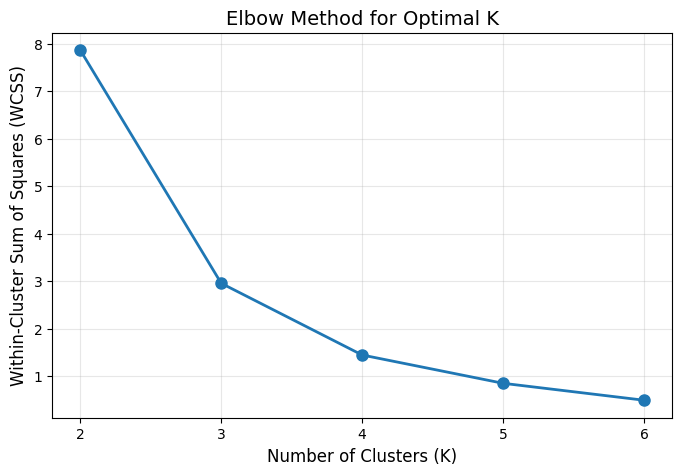


Optimal K selected: 3 (based on elbow point at K=3)

Final Clustered Dataset:
   student_id  GPA  study_hours  attendance_rate  cluster
0           1  3.5           30               90        2
1           2  2.1           10               60        1
2           3  3.8           40               95        2
3           4  2.5           15               65        1
4           5  3.2           25               85        0
5           6  1.8            8               50        1
6           7  3.9           45               98        2
7           8  2.9           20               70        0
8           9  3.0           22               75        0
9          10  2.2           12               55        1

Cluster Centers (original scale):
        GPA  study_hours  attendance_rate  cluster
0  3.033333    22.333333        76.666667        0
1  2.150000    11.250000        57.500000        1
2  3.733333    38.333333        94.333333        2


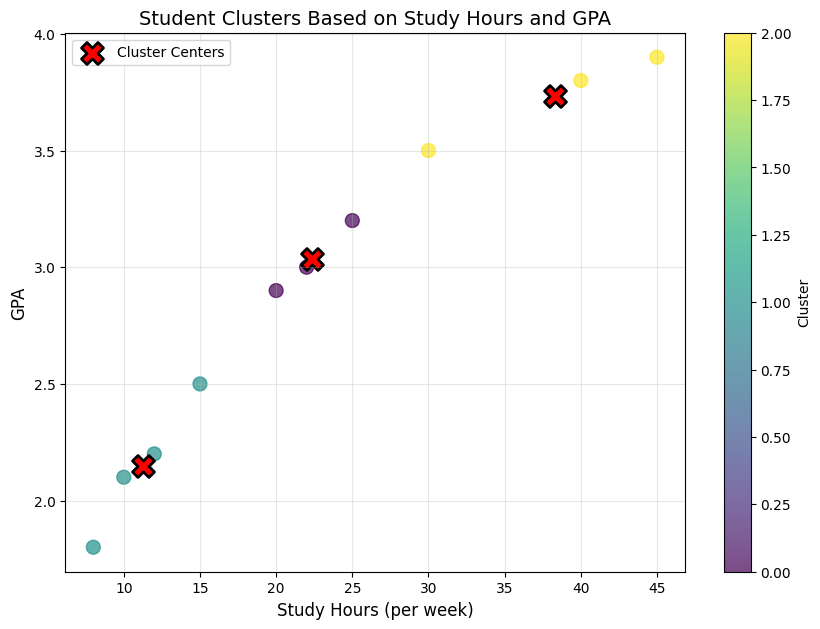


Cluster 0: 3 students
  Avg GPA: 3.03
  Avg Study Hours: 22.3
  Avg Attendance: 76.7%

Cluster 1: 4 students
  Avg GPA: 2.15
  Avg Study Hours: 11.2
  Avg Attendance: 57.5%

Cluster 2: 3 students
  Avg GPA: 3.73
  Avg Study Hours: 38.3
  Avg Attendance: 94.3%


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("\n================ TASK 3: STUDENT CLUSTERING ================")

df = pd.DataFrame({
    "student_id": range(1,11),
    "GPA": [3.5, 2.1, 3.8, 2.5, 3.2, 1.8, 3.9, 2.9, 3.0, 2.2],
    "study_hours": [30,10,40,15,25,8,45,20,22,12],
    "attendance_rate": [90,60,95,65,85,50,98,70,75,55]
})

print("\nOriginal Dataset:")
print(df)

X = df[["GPA", "study_hours", "attendance_rate"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
k_range = range(2, 7)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("\nElbow Method Results:")
for k, w in zip(k_range, wcss):
    print(f"K={k}: WCSS={w:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker="o", linewidth=2, markersize=8)
plt.title("Elbow Method for Optimal K", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Within-Cluster Sum of Squares (WCSS)", fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

k_opt = 3
print(f"\nOptimal K selected: {k_opt} (based on elbow point at K=3)")

kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("\nFinal Clustered Dataset:")
print(df[["student_id", "GPA", "study_hours", "attendance_rate", "cluster"]])

print("\nCluster Centers (original scale):")
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=["GPA", "study_hours", "attendance_rate"])
centers_df["cluster"] = range(k_opt)
print(centers_df)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df["study_hours"], df["GPA"], c=df["cluster"], cmap="viridis", s=100, alpha=0.7)
plt.scatter(centers_df["study_hours"], centers_df["GPA"], c="red", marker="X", s=250, edgecolors="black", linewidths=2, label="Cluster Centers")
plt.title("Student Clusters Based on Study Hours and GPA", fontsize=14)
plt.xlabel("Study Hours (per week)", fontsize=12)
plt.ylabel("GPA", fontsize=12)
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for i in range(k_opt):
    cluster_students = df[df["cluster"] == i]
    print(f"\nCluster {i}: {len(cluster_students)} students")
    print(f"  Avg GPA: {cluster_students['GPA'].mean():.2f}")
    print(f"  Avg Study Hours: {cluster_students['study_hours'].mean():.1f}")
    print(f"  Avg Attendance: {cluster_students['attendance_rate'].mean():.1f}%")